# **Portuguese Bank Marketing** 🏦

## 📊 Dataset Overview

This dataset contains information about **direct marketing campaigns** (phone calls) conducted by a Portuguese banking institution. The goal of the campaign was to promote **term deposit subscriptions** — a financial product that boosts bank revenue.

The target variable is `y`, which indicates whether the client **subscribed to a term deposit**:
- `yes`: client subscribed
- `no`: client did not subscribe

---

## 📁 Dataset Shape
- **Rows**: 32,950  
- **Columns**: 16

---

## 🔍 Feature Description

| Column        | Description |
|---------------|-------------|
| `age`         | Age of the client (numeric) |
| `job`         | Type of job (admin, technician, retired, etc.) |
| `marital`     | Marital status (married, single, divorced) |
| `education`   | Education level (basic, high school, university) |
| `default`     | Has credit in default? (yes, no, unknown) |
| `housing`     | Has a housing loan? (yes or no) |
| `loan`        | Has a personal loan? (yes or no) |
| `contact`     | Communication type (cellular or telephone) |
| `month`       | Last contact month (e.g., may, jun) |
| `day_of_week` | Last contact day of the week (e.g., mon, tue) |
| `duration`    | Duration of the last contact in seconds — ⚠️ *should not be used in training* (leaks info) |
| `campaign`    | Number of contacts performed during this campaign |
| `pdays`       | Days since the client was last contacted (-1 means never contacted before) |
| `previous`    | Number of contacts before this campaign |
| `poutcome`    | Outcome of the previous marketing campaign |
| `y`           | **Target**: Has the client subscribed to a term deposit? (yes/no) |

## Imports

### Data Manipulation and Visualization

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as mgno

### Pre-Processing

In [ ]:
from sklearn import preprocessing
from sklearn.model_selection import (
    train_test_split, 
    GridSearchCV, 
    RandomizedSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.decomposition import PCA

### Models

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree)
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

### Metrics

In [4]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

In [5]:
df = pd.read_csv('Datasets\\Bank Marketing (2).csv')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,y
0,49,blue-collar,married,basic.9y,unknown,no,no,cellular,nov,wed,227,4,999,0,nonexistent,no
1,37,entrepreneur,married,university.degree,no,no,no,telephone,nov,wed,202,2,999,1,failure,no
2,78,retired,married,basic.4y,no,no,no,cellular,jul,mon,1148,1,999,0,nonexistent,yes
3,36,admin.,married,university.degree,no,yes,no,telephone,may,mon,120,2,999,0,nonexistent,no
4,59,retired,divorced,university.degree,no,no,no,cellular,jun,tue,368,2,999,0,nonexistent,no


## EDA

### Data Info

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32950 entries, 0 to 32949
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          32950 non-null  int64 
 1   job          32950 non-null  object
 2   marital      32950 non-null  object
 3   education    32950 non-null  object
 4   default      32950 non-null  object
 5   housing      32950 non-null  object
 6   loan         32950 non-null  object
 7   contact      32950 non-null  object
 8   month        32950 non-null  object
 9   day_of_week  32950 non-null  object
 10  duration     32950 non-null  int64 
 11  campaign     32950 non-null  int64 
 12  pdays        32950 non-null  int64 
 13  previous     32950 non-null  int64 
 14  poutcome     32950 non-null  object
 15  y            32950 non-null  object
dtypes: int64(5), object(11)
memory usage: 4.0+ MB


### Nulls

In [8]:
df.isnull().sum()

age            0
job            0
marital        0
education      0
default        0
housing        0
loan           0
contact        0
month          0
day_of_week    0
duration       0
campaign       0
pdays          0
previous       0
poutcome       0
y              0
dtype: int64

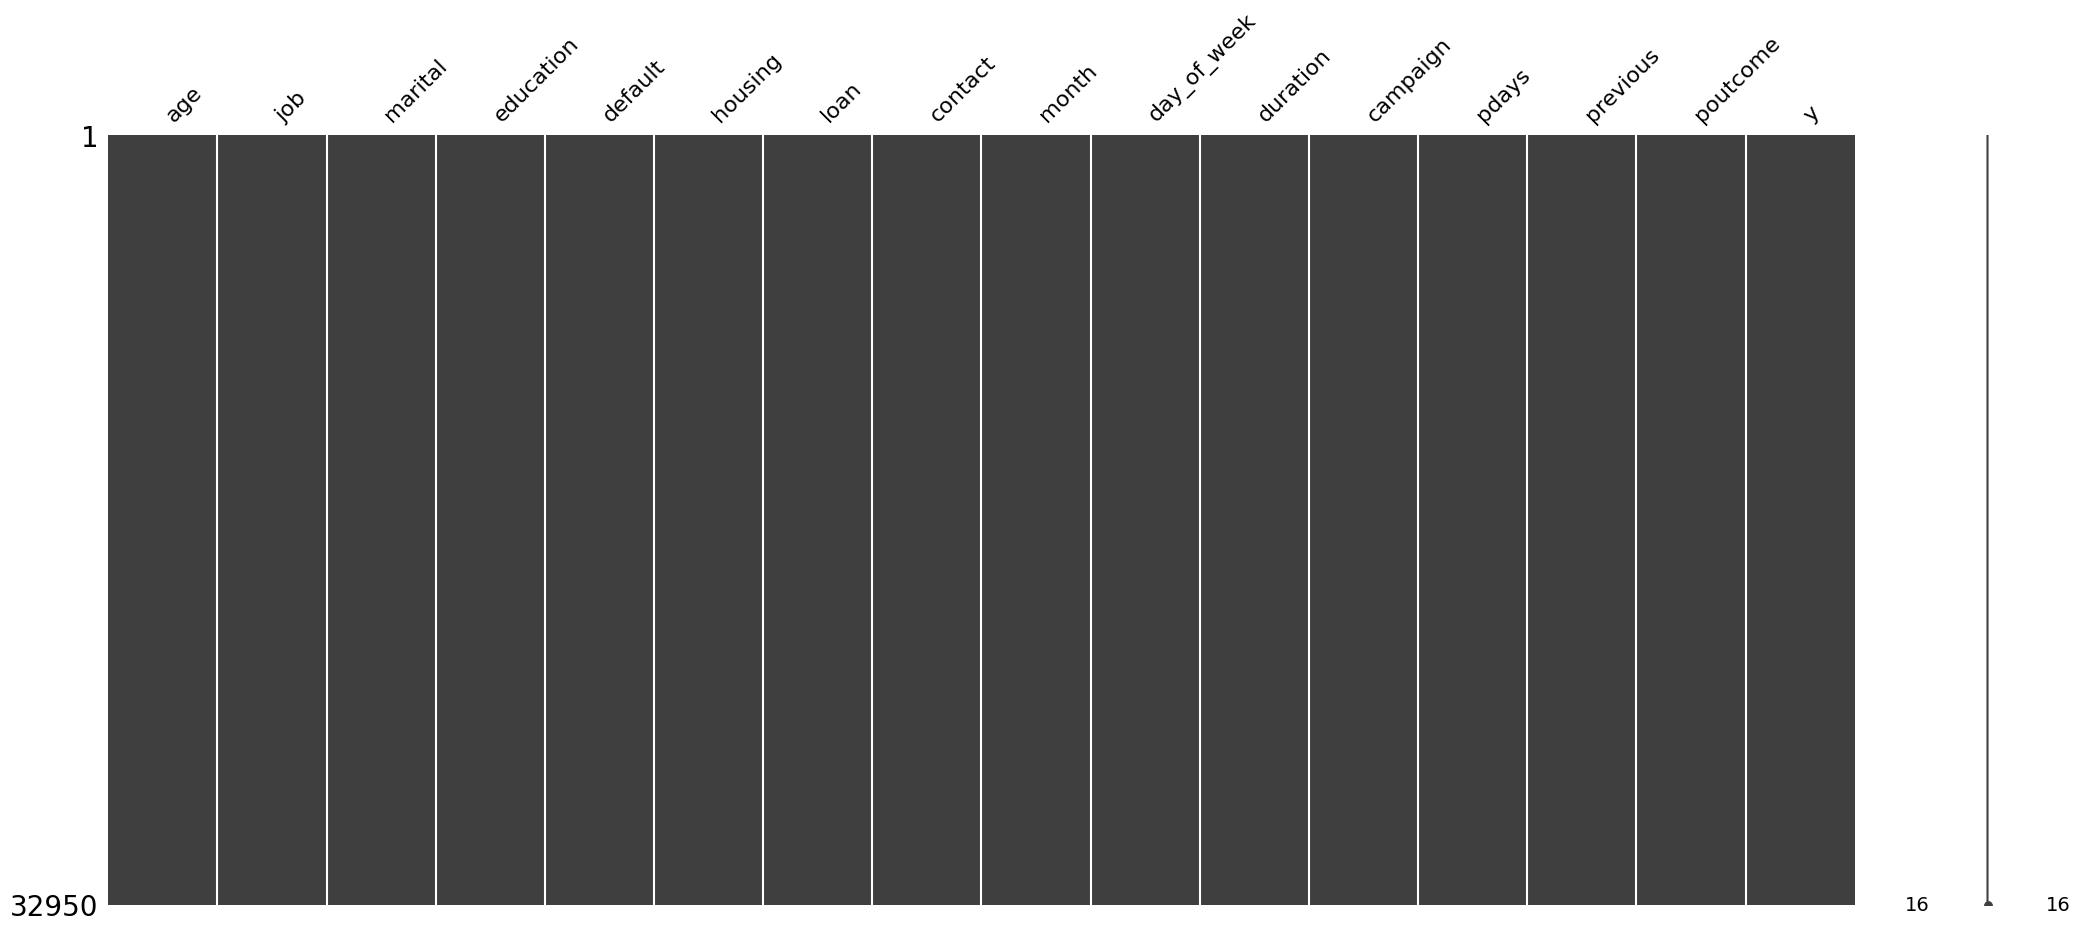

In [13]:
mgno.matrix(df)
plt.show()

### Duplicates

In [10]:
df.duplicated().sum()

np.int64(8)

In [14]:
df.drop_duplicates(inplace=True)

In [21]:
numeric_features = df.select_dtypes(include=np.number).columns
categorical_features = df.select_dtypes(include='object').columns
print("Numeric Features:")
print(numeric_features)
print("=============================================")
print("Categorical Features:")
display(categorical_features)

Numeric Features:
Index(['age', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')
Categorical Features:


Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')